# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Exploratory Data Analysis

Using the [feature engineered dataset](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.txt), we tidy the dataset for the exploratory data analysis.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from nn_tools.utils.plotutils import *

In [2]:
sns.set()
ratio   = lambda x, y: (6 * y, 5 * x)

os.makedirs('./img', exist_ok=True)
os.makedirs('./models', exist_ok=True)

## Download the Dataset

We download the dataset containing the engineered features of CICY 4-folds.
Since the dataset is large we start by considering only the scalar **engineered features** (see the [documentation](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.txt) for the name of the columns).

In [3]:
df = pd.read_json('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz', orient='index')

In [4]:
df = df.drop(columns=df.loc[:,df.dtypes == 'object'].columns)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 921497 entries, 1 to 921497
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   euler           921497 non-null  int64  
 1   favour          921497 non-null  bool   
 2   h11             905684 non-null  float64
 3   h21             905684 non-null  float64
 4   h22             905684 non-null  float64
 5   h31             905684 non-null  float64
 6   isprod          921497 non-null  bool   
 7   num_cp          921497 non-null  int64  
 8   num_eqs         921497 non-null  int64  
 9   num_cp_1        921497 non-null  int64  
 10  num_cp_2        921497 non-null  int64  
 11  num_cp_neq1     921497 non-null  int64  
 12  num_ex          921497 non-null  int64  
 13  norm_matrix     921497 non-null  float64
 14  rank_matrix     921497 non-null  int64  
 15  min_dim_cp      921497 non-null  int64  
 16  max_dim_cp      921497 non-null  int64  
 17  mean_dim_c

## Complete Cases

In the dataset there are incomplete cases for $h^{1,1}$, $h^{2,1}$, $h^{3,1}$ and $h^{2,2}$.

In [6]:
df.isna().sum()

euler                 0
favour                0
h11               15813
h21               15813
h22               15813
h31               15813
isprod                0
num_cp                0
num_eqs               0
num_cp_1              0
num_cp_2              0
num_cp_neq1           0
num_ex                0
norm_matrix           0
rank_matrix           0
min_dim_cp            0
max_dim_cp            0
mean_dim_cp           0
std_dim_cp            0
median_dim_cp         0
min_deg_eqs           0
max_deg_eqs           0
mean_deg_eqs          0
std_deg_eqs           0
median_deg_eqs        0
dtype: int64

For the exploratory data analysis we investigate on their nature:

In [7]:
df.loc[df['isprod'] == True, 'h11':'h31'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15813 entries, 41 to 919969
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   h11     0 non-null      float64
 1   h21     0 non-null      float64
 2   h22     0 non-null      float64
 3   h31     0 non-null      float64
dtypes: float64(4)
memory usage: 617.7 KB


In [8]:
df.loc[df['isprod'] == False, 'h11':'h31'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 905684 entries, 1 to 921497
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   h11     905684 non-null  float64
 1   h21     905684 non-null  float64
 2   h22     905684 non-null  float64
 3   h31     905684 non-null  float64
dtypes: float64(4)
memory usage: 34.5 MB


As we can see the incomplete cases are fully linked to the configuration matrix being a product space.
We can therefore discard the corresponding rows from the dataset:

In [9]:
df = df.loc[df['isprod'] == False].drop(columns=['isprod'])

## Data Types Conversion

We then convert the data types of the Hodge numbers for optimisation.

In [10]:
df['h11'] = df['h11'].astype(np.int)
df['h21'] = df['h21'].astype(np.int)
df['h31'] = df['h31'].astype(np.int)
df['h22'] = df['h22'].astype(np.int)

## Distribution of the Labels

As a first analysis we provide the univariate distributions of the labels:

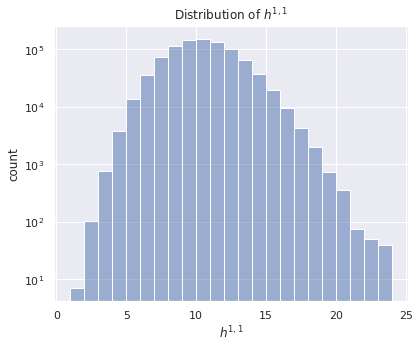

In [11]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=df['h11'],
             binwidth=1,
             color='C0',
             alpha=0.5,
             ax=ax
            )
ax.set(title='Distribution of $h^{1,1}$',
       xlabel='$h^{1,1}$',
       ylabel='count',
       yscale='log'
      )

savefig('distr_h11', fig, show=True)

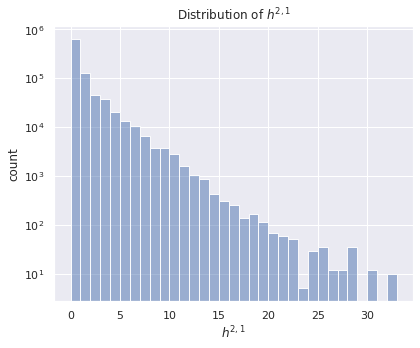

In [12]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=df['h21'],
             binwidth=1,
             color='C0',
             alpha=0.5,
             ax=ax
            )
ax.set(title='Distribution of $h^{2,1}$',
       xlabel='$h^{2,1}$',
       ylabel='count',
       yscale='log'
      )

savefig('distr_h21', fig, show=True)

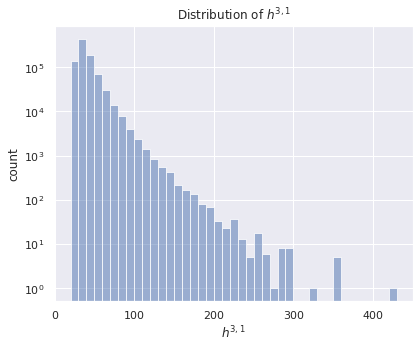

In [13]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=df['h31'],
             binwidth=10,
             color='C0',
             alpha=0.5,
             ax=ax
            )
ax.set(title='Distribution of $h^{3,1}$',
       xlabel='$h^{3,1}$',
       ylabel='count',
       yscale='log'
      )

savefig('distr_h31', fig, show=True)

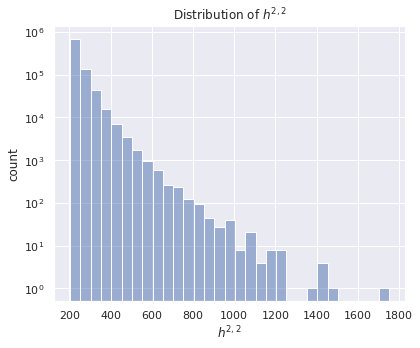

In [14]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.histplot(data=df['h22'],
             binwidth=50,
             color='C0',
             alpha=0.5,
             ax=ax
            )
ax.set(title='Distribution of $h^{2,2}$',
       xlabel='$h^{2,2}$',
       ylabel='count',
       yscale='log'
      )

savefig('distr_h22', fig, show=True)

## Distributions of the Values

We then look at the distribution of the values of the labels in more detail.
Specifically, we show the top 5 Hodge numbers in frequency.

In [15]:
df[['h11', 'num_cp']].groupby(by=['h11']).count().sort_values(by=['num_cp'], ascending=False).apply(lambda x: x / x.sum()).head(5)

,num_cp
h11,
10,0.167218
9,0.159483
11,0.146515
8,0.125502
12,0.110053


In [16]:
df[['h21', 'num_cp']].groupby(by=['h21']).count().sort_values(by=['num_cp'], ascending=False).apply(lambda x: x / x.sum()).head(5)

,num_cp
h21,
0,0.700535
1,0.136593
2,0.049948
3,0.040652
4,0.021989


In [17]:
df[['h31', 'num_cp']].groupby(by=['h31']).count().sort_values(by=['num_cp'], ascending=False).apply(lambda x: x / x.sum()).head(5)

,num_cp
h31,
32,0.059509
34,0.054964
30,0.054447
31,0.053767
33,0.052687


In [18]:
df[['h22', 'num_cp']].groupby(by=['h22']).count().sort_values(by=['num_cp'], ascending=False).apply(lambda x: x / x.sum()).head(5)

,num_cp
h22,
204,0.106830
216,0.085727
228,0.070361
208,0.049807
212,0.047837


As we can see $h^{2,1}$ vanishes ~70% of the times.
This will indeed be a difficult number to predict well.

## Correlations and Covariance

Given the distributions we then study the correlations between the variables.

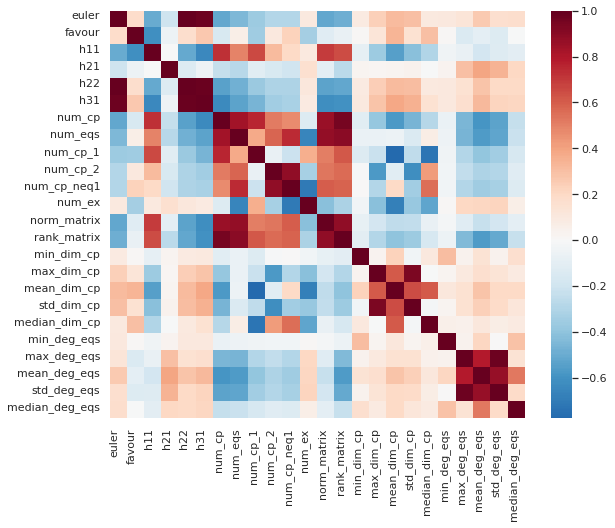

In [19]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1.5,1.5))

corr_mat = df.corr()
sns.heatmap(corr_mat,
            center=0.0,
            cmap='RdBu_r',
            ax=ax
           )
ax.set(title='',
       xticks=range(len(corr_mat.columns)),
       yticks=range(len(corr_mat.columns))
      )
ax.set_xticklabels(corr_mat.columns, rotation=90, va='top', ha='left')
ax.set_yticklabels(corr_mat.columns, va='top', ha='right')

savefig('corr_eng_feat', fig, show=True)

As usual the engineered features look correlated.
In particular correlation of features of the same "type" is more pronounced.

## Distribution of the Features

We then study the distribution of features with respect to the labels.

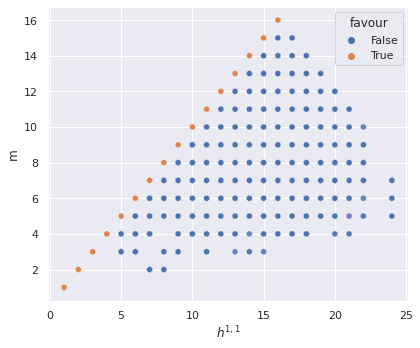

In [20]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h11',
                y='num_cp',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{1,1}$',
       ylabel='m'
      )
savefig('num_cp_vs_h11', fig, show=True)

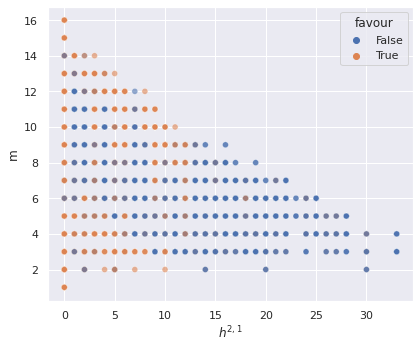

In [21]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h21',
                y='num_cp',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{2,1}$',
       ylabel='m'
      )
savefig('num_cp_vs_h21', fig, show=True)

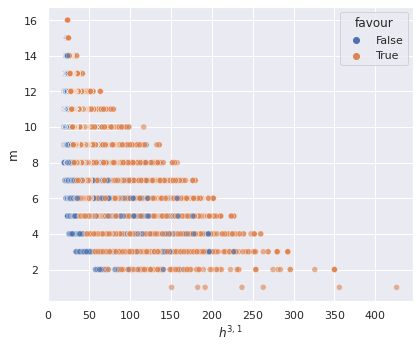

In [22]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h31',
                y='num_cp',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{3,1}$',
       ylabel='m'
      )
savefig('num_cp_vs_h31', fig, show=True)

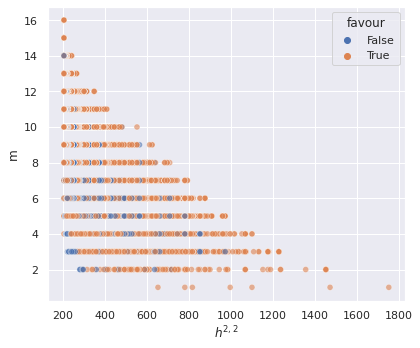

In [23]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h22',
                y='num_cp',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{2,2}$',
       ylabel='m'
      )
savefig('num_cp_vs_h22', fig, show=True)

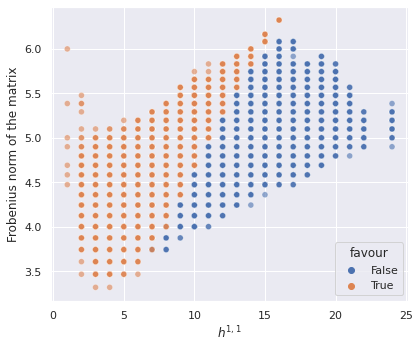

In [24]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h11',
                y='norm_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{1,1}$',
       ylabel='Frobenius norm of the matrix'
      )
savefig('norm_matrix_vs_h11', fig, show=True)

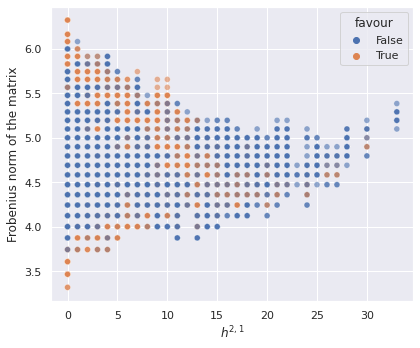

In [25]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h21',
                y='norm_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{2,1}$',
       ylabel='Frobenius norm of the matrix'
      )
savefig('norm_matrix_vs_h21', fig, show=True)

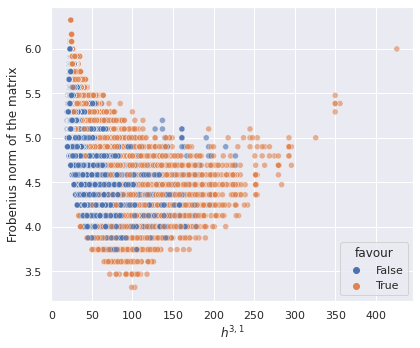

In [26]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h31',
                y='norm_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{3,1}$',
       ylabel='Frobenius norm of the matrix'
      )
savefig('norm_matrix_vs_h31', fig, show=True)

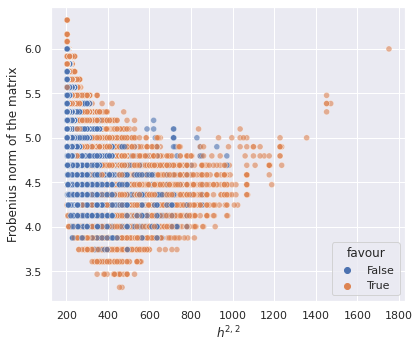

In [27]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h22',
                y='norm_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{2,2}$',
       ylabel='Frobenius norm of the matrix'
      )
savefig('norm_matrix_vs_h22', fig, show=True)

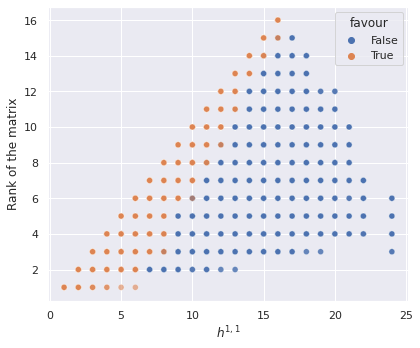

In [28]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h11',
                y='rank_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{1,1}$',
       ylabel='Rank of the matrix'
      )
savefig('rank_matrix_vs_h11', fig, show=True)

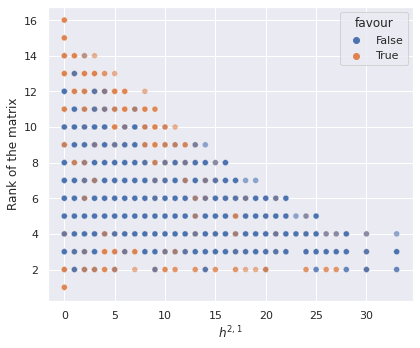

In [29]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h21',
                y='rank_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{2,1}$',
       ylabel='Rank of the matrix'
      )
savefig('rank_matrix_vs_h21', fig, show=True)

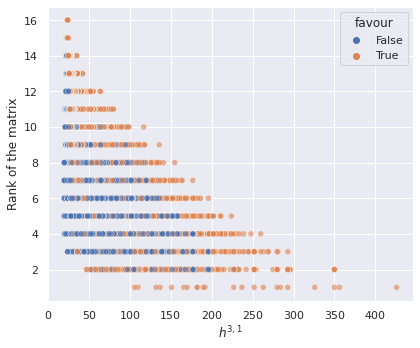

In [30]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h31',
                y='rank_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{3,1}$',
       ylabel='Rank of the matrix'
      )
savefig('rank_matrix_vs_h31', fig, show=True)

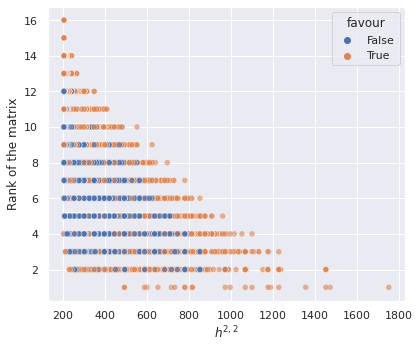

In [31]:
fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

sns.scatterplot(data=df,
                x='h22',
                y='rank_matrix',
                hue='favour',
                alpha=0.6,
                ax=ax
               )
ax.set(title='',
       xlabel='$h^{2,2}$',
       ylabel='Rank of the matrix'
      )
savefig('rank_matrix_vs_h22', fig, show=True)